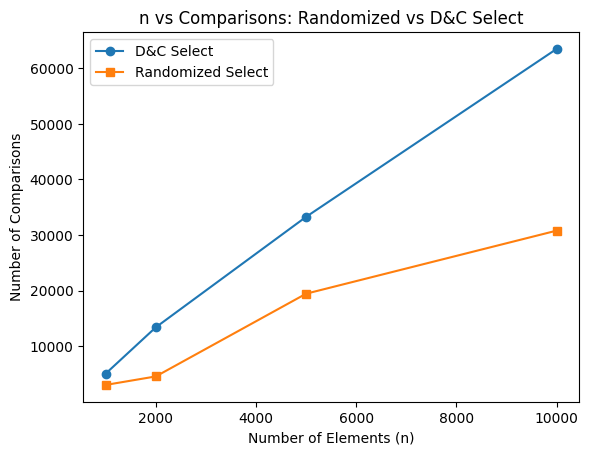

In [1]:
import random
import matplotlib.pyplot as plt


class DeterministicSelect:
    def __init__(self):
        self.comparisons = 0

    def partition_around(self, A, p, r, x):
        pivot_index = A.index(x, p, r + 1)
        A[pivot_index], A[r] = A[r], A[pivot_index]

        i = p - 1
        for j in range(p, r):
            self.comparisons += 1
            if A[j] <= x:
                i += 1
                A[i], A[j] = A[j], A[i]

        A[i + 1], A[r] = A[r], A[i + 1]
        return i + 1

    def select(self, arr, p, r, i):
        while (r - p + 1) % 5 != 0:
            for j in range(p + 1, r + 1):
                self.comparisons += 1
                if arr[j] < arr[p]:
                    arr[j], arr[p] = arr[p], arr[j]
            if i == 1:
                return arr[p]
            p += 1
            i -= 1

        g = (r - p + 1) // 5

        for j in range(p, p + g):
            group = [arr[j + k * g] for k in range(5)]
            # insertion sort (count comparisons)
            '''
            for a in range(1, 5):
                key = group[a]
                b = a - 1
                while b >= 0:
                    self.comparisons += 1
                    if group[b] > key:
                        group[b + 1] = group[b]
                        b -= 1
                    else:
                        break
                group[b + 1] = key
            '''
            group.sort()
            for k in range(5):
                arr[j + k * g] = group[k]

        mid = (g + 1) // 2
        x = self.select(arr, p + 2 * g, p + 3 * g - 1, mid)

        q = self.partition_around(arr, p, r, x)
        k = q - p + 1

        if i == k:
            return x
        elif i < k:
            return self.select(arr, p, q - 1, i)
        else:
            return self.select(arr, q + 1, r, i - k)

class randomized_select:
    def __init__(self):
        self.comparisons = 0

    def random_partition(self,A,p,r):
        random_index = random.randint(p, r)

        A[random_index], A[r] = A[r], A[random_index]
        return self._partition(A,p,r)

    def _partition(self,A,p,r):
        x = A[r]
        i = p - 1
        for j in range(p,r):
            self.comparisons += 1
            if A[j] <= x:
                i += 1
                A[i],A[j] = A[j],A[i]
        A[i+1],A[r] = A[r],A[i+1]
        return i+1
    def randomized_select(self, A, p ,r, i ):
        if p == r:
            return A[p]
        q = self.random_partition(A,p,r)
        k = q - p + 1
        if i == k:
            return A[q]
        elif i < k:
            return self.randomized_select(A,p,q-1,i)
        else:
            return self.randomized_select(A,q+1,r,i-k)



def generate_array(n):
    return random.sample(range(1, n * 10), n)


sizes = [1000, 2000, 5000, 10000]
dc_comparisons_list = []
r_comparisons_list = []

for n in sizes:
    arr = generate_array(n)

    arr1 = arr.copy()
    dc_selector = DeterministicSelect()
    dc_selector.select(arr1, 0, n - 1, n // 2)
    dc_comparisons_list.append(dc_selector.comparisons)

    r_selector = randomized_select()
    r_selector.randomized_select(arr, 0, n - 1, n//2)
    r_comparisons_list.append(r_selector.comparisons)


plt.figure()
plt.plot(sizes, dc_comparisons_list, marker='o',label = "D&C Select")
plt.plot(sizes, r_comparisons_list,marker = 's', label = "Randomized Select")
plt.xlabel("Number of Elements (n)")
plt.ylabel("Number of Comparisons")
plt.title("n vs Comparisons: Randomized vs D&C Select")
plt.legend()
plt.show()
plt.show()
